In [4]:
import os
print(os.getcwd())  # This prints the current working directory


/content


Checked for missing values and handled them (**filled numerical with median, categorical with mode**).
Removed outliers using the **99th percentile and IQR method for LotArea, TotalBsmtSF, and SalePrice**.
Applied **log transformation to skewed features** (LotArea, TotalBsmtSF, SalePrice).
Encoded **categorical variables** (possibly using Label Encoding or One-Hot Encoding).
Created **new features** like HouseAge, TotalSF, and RoomsPerSF.
Standardized numerical features using **RobustScaler**.

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor, StackingRegressor
from sklearn.ensemble import GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [6]:
file_name = "/content/HousePricePrediction(Sheet1).csv"
data = pd.read_csv(file_name)
print(data.head())


   Id  MSSubClass MSZoning  LotArea LotConfig BldgType  OverallCond  \
0   0          60       RL     8450    Inside     1Fam            5   
1   1          20       RL     9600       FR2     1Fam            8   
2   2          60       RL    11250    Inside     1Fam            5   
3   3          70       RL     9550    Corner     1Fam            5   
4   4          60       RL    14260       FR2     1Fam            5   

   YearBuilt  YearRemodAdd Exterior1st  BsmtFinSF2  TotalBsmtSF  SalePrice  
0       2003          2003     VinylSd         0.0        856.0   208500.0  
1       1976          1976     MetalSd         0.0       1262.0   181500.0  
2       2001          2002     VinylSd         0.0        920.0   223500.0  
3       1915          1970     Wd Sdng         0.0        756.0   140000.0  
4       2000          2000     VinylSd         0.0       1145.0   250000.0  


In [7]:
# Check for missing data in the dataset
missing_data = data.isnull().sum()

# Display columns with missing values and the number of missing entries
missing_data = missing_data[missing_data > 0]
missing_data


,0
MSZoning,4
Exterior1st,1
BsmtFinSF2,1
TotalBsmtSF,1
SalePrice,1459


In [8]:
# Fill missing categorical features with the mode (most frequent value)
data['MSZoning'].fillna(data['MSZoning'].mode()[0], inplace=True)
data['Exterior1st'].fillna(data['Exterior1st'].mode()[0], inplace=True)

# Fill missing numerical features with the median value
data['BsmtFinSF2'].fillna(data['BsmtFinSF2'].median(), inplace=True)
data['TotalBsmtSF'].fillna(data['TotalBsmtSF'].median(), inplace=True)

# Verify that missing values have been handled (except for SalePrice)
missing_data_after = data.isnull().sum()
missing_data_after = missing_data_after[missing_data_after > 0]
missing_data_after


/tmp/ipykernel_21625/977240643.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['MSZoning'].fillna(data['MSZoning'].mode()[0], inplace=True)
/tmp/ipykernel_21625/977240643.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inp

,0
SalePrice,1459


In [9]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
for col in data.select_dtypes(include=['object']).columns:
    data[col] = label_encoder.fit_transform(data[col])

In [10]:
# Relevant columns for the analysis
relevant_columns = [
    'MSZoning',       # Location
    'LotArea',        # Location
    'LotConfig',      # Location
    'BldgType',       # Property Details
    'YearBuilt',      # Property Details
    'YearRemodAdd',   # Property Details
    'OverallCond',    # Property Details
    'Exterior1st',    # Property Details
    'BsmtFinSF2',     # Property Details
    'TotalBsmtSF',    # Property Details
    'SalePrice'       # Target variable (if needed)
]


In [11]:
# Filter the dataset to keep only relevant columns
cleaned_data = data[relevant_columns]

# Save the filtered dataset to a new file
cleaned_data.to_csv('Filtered_HousePricePrediction.csv', index=False)

print("Filtered dataset saved as 'Filtered_HousePricePrediction.csv'")


Filtered dataset saved as 'Filtered_HousePricePrediction.csv'


In [12]:
# Summary statistics
summary_stats = data.describe()
print("\nSummary Statistics:\n", summary_stats)


Summary Statistics:
                 Id   MSSubClass     MSZoning        LotArea    LotConfig  \
count  2919.000000  2919.000000  2919.000000    2919.000000  2919.000000   
mean   1459.000000    57.137718     3.027749   10168.114080     3.055841   
std     842.787043    42.517628     0.658355    7886.996359     1.604472   
min       0.000000    20.000000     0.000000    1300.000000     0.000000   
25%     729.500000    20.000000     3.000000    7478.000000     2.000000   
50%    1459.000000    50.000000     3.000000    9453.000000     4.000000   
75%    2188.500000    70.000000     3.000000   11570.000000     4.000000   
max    2918.000000   190.000000     4.000000  215245.000000     4.000000   

          BldgType  OverallCond    YearBuilt  YearRemodAdd  Exterior1st  \
count  2919.000000  2919.000000  2919.000000   2919.000000  2919.000000   
mean      0.505653     5.564577  1971.312778   1984.264474     9.624186   
std       1.206513     1.113131    30.291442     20.894344     3.199

In [13]:
# Feature Engineering

# 1. Create new feature: House Age
data["HouseAge"] = 2025 - data["YearBuilt"]

# 2. Create a feature: Remodeling Age (years since last remodeling)
data["RemodelAge"] = 2025 - data["YearRemodAdd"]

# 3. Total Basement Area: Combine relevant features
data["TotalBsmtArea"] = data["BsmtFinSF2"] + data["TotalBsmtSF"]

# 4. Log Transformation of SalePrice to handle skewness (for modeling)

data["LogSalePrice"] = np.log1p(data["SalePrice"])

# 5. Feature Interaction: LotArea per Room
data["LotAreaPerRoom"] = data["LotArea"] / (data["OverallCond"] + 1)  # Avoid division by zero

# Display the updated dataset with new features
# Instead of using ace_tools, display the first few rows using .head()
print("Feature Engineered Dataset:")
print(data.head())  # Display first 5 rows
# print the entire dataframe
print(data)



Feature Engineered Dataset:
   Id  MSSubClass  MSZoning  LotArea  LotConfig  BldgType  OverallCond  \
0   0          60         3     8450          4         0            5   
1   1          20         3     9600          2         0            8   
2   2          60         3    11250          4         0            5   
3   3          70         3     9550          0         0            5   
4   4          60         3    14260          2         0            5   

   YearBuilt  YearRemodAdd  Exterior1st  BsmtFinSF2  TotalBsmtSF  SalePrice  \
0       2003          2003           12         0.0        856.0   208500.0   
1       1976          1976            8         0.0       1262.0   181500.0   
2       2001          2002           12         0.0        920.0   223500.0   
3       1915          1970           13         0.0        756.0   140000.0   
4       2000          2000           12         0.0       1145.0   250000.0   

   HouseAge  RemodelAge  TotalBsmtArea  LogSalePrice

HouseAge: Calculates the age of the house (2025 - YearBuilt).
RemodelAge: Number of years since the last remodeling (2025 - YearRemodAdd).
TotalBsmtArea: Combines BsmtFinSF2 and TotalBsmtSF to get the total basement area.
LogSalePrice: Log transformation of SalePrice to handle skewness (useful for modeling).
LotAreaPerRoom: Lot area divided by the number of rooms (OverallCond + 1 to avoid division by zero).

In [14]:
# Save the modified dataset to a new CSV file
output_file = "Feature_Engineered_HousePriceDataset.csv"
data.to_csv(output_file, index=False)

print(f"Dataset saved as {output_file}")


Dataset saved as Feature_Engineered_HousePriceDataset.csv


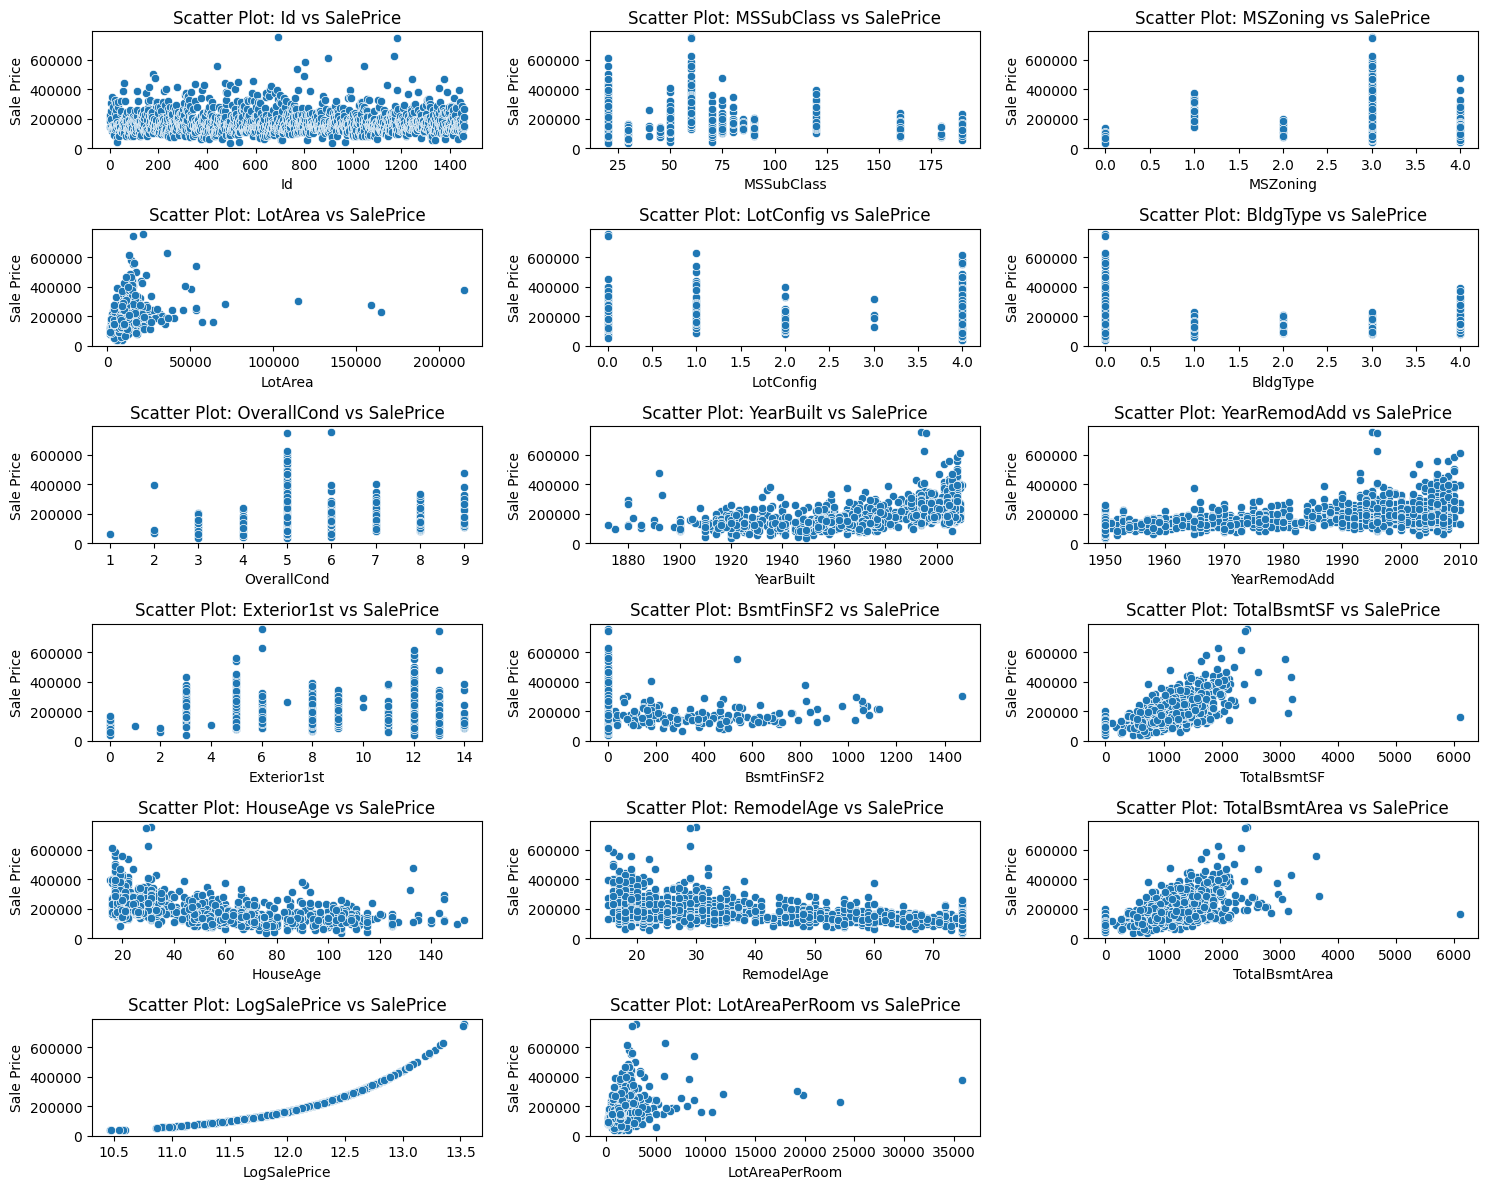

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get numerical columns excluding SalePrice
numerical_features = data.select_dtypes(include=['int64', 'float64']).columns
numerical_features = numerical_features.drop("SalePrice")  # Exclude target variable

# Calculate the number of rows and columns for subplots
num_features = len(numerical_features)
num_cols = 3  # You can adjust this
num_rows = (num_features + num_cols - 1) // num_cols  # Calculate rows needed

# Set up the plot grid with calculated rows and columns
plt.figure(figsize=(15, 12))

# Loop through each numerical feature and plot scatter plot
for i, feature in enumerate(numerical_features, 1):
    plt.subplot(num_rows, num_cols, i)  # Use calculated rows and columns
    sns.scatterplot(x=data[feature], y=data["SalePrice"])
    plt.title(f"Scatter Plot: {feature} vs SalePrice")
    plt.xlabel(feature)
    plt.ylabel("Sale Price")

plt.tight_layout()  # Adjust layout for better spacing
plt.show()

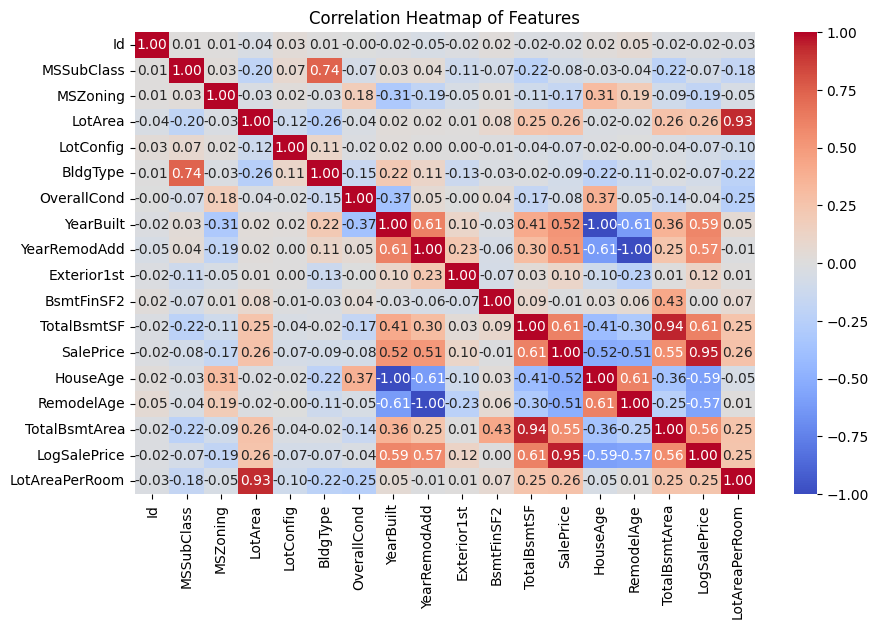

In [16]:
# Correlation matrix
correlation_matrix = data.select_dtypes(include=['number']).corr() # Select only numerical columns

# Plot correlation heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap of Features")
plt.show()

**The code below check th eimbalance and it shows the imbalance is really mild which affects our accuracy for linear regression but XG bosst or regeression handlees it in much better way **

In [17]:
# Select categorical features (integer encoded)
categorical_features = data.select_dtypes(include=['int64']).columns

# Thresholds for imbalance severity
mild_threshold = 0.7
severe_threshold = 0.9

imbalance_report = []

for col in categorical_features:
    value_counts = data[col].value_counts(normalize=True)
    max_ratio = value_counts.max()

    if max_ratio >= severe_threshold:
        severity = "Severe imbalance"
    elif max_ratio >= mild_threshold:
        severity = "Mild imbalance"
    else:
        severity = "Balanced"

    imbalance_report.append({
        'Feature': col,
        'Dominant Class Ratio': round(max_ratio, 3),
        'Severity': severity
    })

# Convert to DataFrame
imbalance_df = pd.DataFrame(imbalance_report)

# Display the imbalance summary
print("Class Imbalance Summary:\n")
print(imbalance_df)


Class Imbalance Summary:

         Feature  Dominant Class Ratio        Severity
0             Id                 0.000        Balanced
1     MSSubClass                 0.370        Balanced
2       MSZoning                 0.777  Mild imbalance
3        LotArea                 0.015        Balanced
4      LotConfig                 0.731  Mild imbalance
5       BldgType                 0.831  Mild imbalance
6    OverallCond                 0.564        Balanced
7      YearBuilt                 0.049        Balanced
8   YearRemodAdd                 0.124        Balanced
9    Exterior1st                 0.351        Balanced
10      HouseAge                 0.049        Balanced
11    RemodelAge                 0.124        Balanced


In [18]:
# Load the dataset
data = pd.read_csv("/content/Feature_Engineered_HousePriceDataset.csv")
# Drop rows where SalePrice is missing
data = data.dropna(subset=['SalePrice'])

# Define features (X) and target (y)
X = data.drop(columns=['SalePrice'])
y = data['SalePrice']

In [19]:
# Split data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize numerical features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Define Base Models for ensemble
base_models = [
    ('linear_regression', LinearRegression()),
    ('decision_tree', DecisionTreeRegressor(random_state=42)),
    ('xgboost', XGBRegressor(n_estimators=100, learning_rate=0.05, random_state=42))
]
# Meta Model (Final Estimator)
meta_model = RandomForestRegressor(n_estimators=100, random_state=42)

# Stacking Regressor
stacking_model = StackingRegressor(
    estimators=base_models,
    final_estimator=meta_model,
    cv=5  # Cross-validation
)
# Initialize the models
linear_reg = LinearRegression()
decision_tree = DecisionTreeRegressor(random_state=42)
xgb_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)
# Train the models and make predictions
linear_reg.fit(X_train, y_train)
y_pred_lr = linear_reg.predict(X_test)

decision_tree.fit(X_train, y_train)
y_pred_dt = decision_tree.predict(X_test)

xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)

stacking_model.fit(X_train, y_train)
y_pred_stm = stacking_model.predict(X_test)


In [20]:
# Define a function to calculate evaluation metrics
def evaluate_model(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    return mae, rmse, r2


# Evaluate each model
results = {
    "Linear Regression": evaluate_model(y_test, y_pred_lr),
    "Decision Tree": evaluate_model(y_test, y_pred_dt),

    "XG Boost": evaluate_model(y_true=y_test, y_pred=y_pred_xgb),
      "Ensemble_model": evaluate_model(y_true=y_test, y_pred=y_pred_stm)
}

# Display the results
results_df = pd.DataFrame(results, index=["MAE", "RMSE", "R2"]).T
print("\nModel Performance Comparison:\n")
print(results_df)


Model Performance Comparison:

                            MAE          RMSE        R2
Linear Regression  15701.193897  30580.894649  0.878077
Decision Tree       1518.845890  13426.557044  0.976497
XG Boost            2083.928216   6509.663065  0.994475
Ensemble_model      1202.481199   7007.301677  0.993598


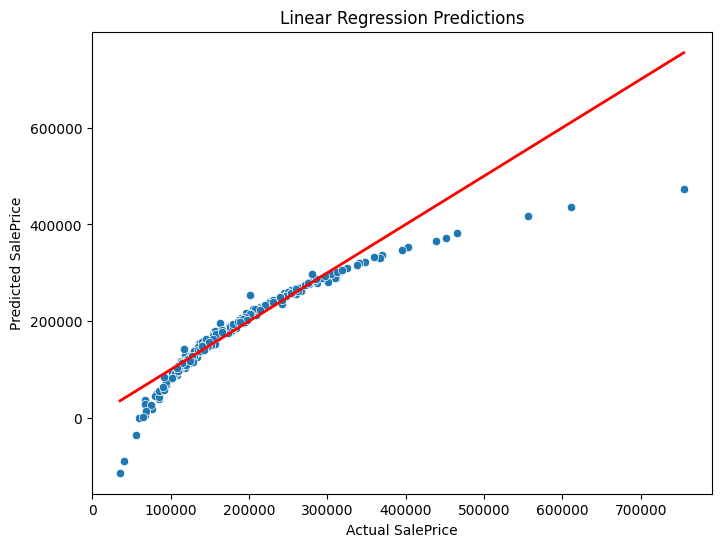

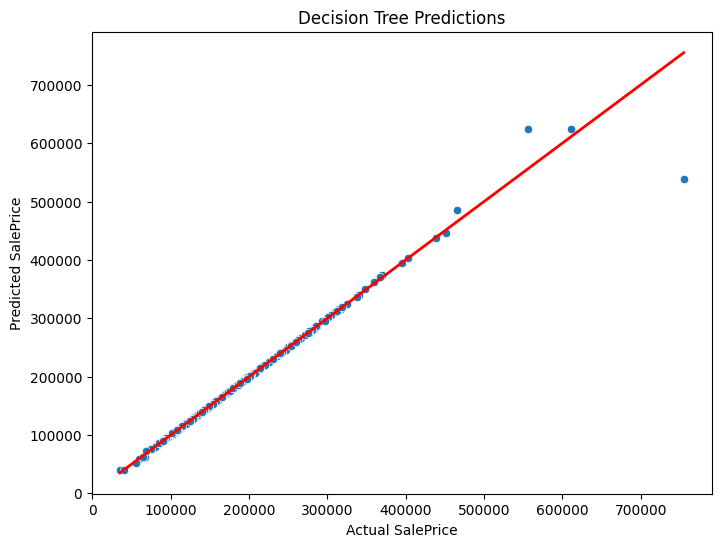

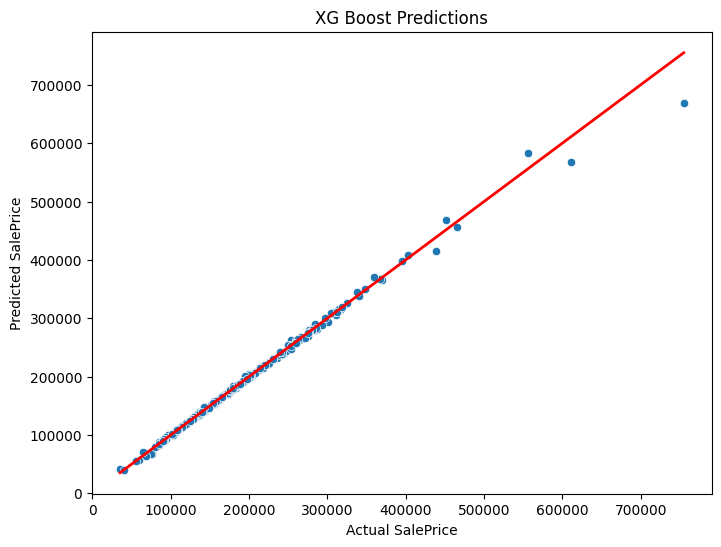

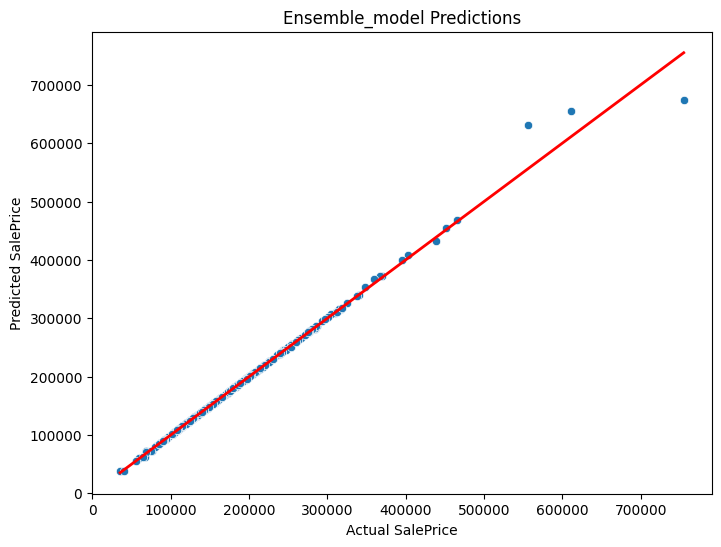

In [21]:
# Visualize predictions
def plot_predictions(y_true, y_pred, title):
    plt.figure(figsize=(8, 6))
    sns.scatterplot(x=y_true, y=y_pred)
    plt.xlabel('Actual SalePrice')
    plt.ylabel('Predicted SalePrice')
    plt.title(title)
    plt.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], color='red', lw=2)
    plt.show()

plot_predictions(y_test, y_pred_lr, 'Linear Regression Predictions')
plot_predictions(y_test, y_pred_dt, 'Decision Tree Predictions')
plot_predictions(y_true=y_test, y_pred=y_pred_xgb, title='XG Boost Predictions')
plot_predictions(y_true=y_test, y_pred=y_pred_stm, title='Ensemble_model Predictions')



MAPE Comparison (Lower is Better):
                    MAPE (%)
Ensemble Model      0.450470
Decision Tree       0.531289
XG Boost            1.011516
Linear Regression  12.490462


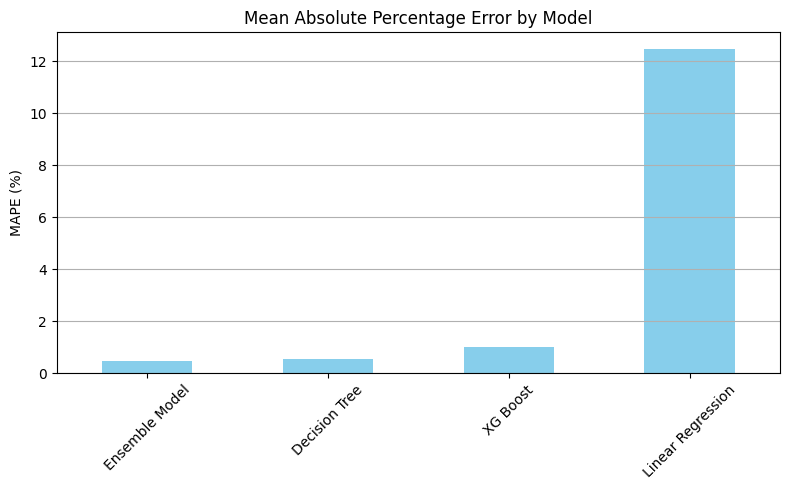

In [22]:
def mean_absolute_percentage_error(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    non_zero = y_true != 0  # To avoid division by zero
    return np.mean(np.abs((y_true[non_zero] - y_pred[non_zero]) / y_true[non_zero])) * 100

# MAPE for each model
mape_lr = mean_absolute_percentage_error(y_test, y_pred_lr)
mape_dt = mean_absolute_percentage_error(y_test, y_pred_dt)
mape_xgb = mean_absolute_percentage_error(y_test, y_pred_xgb)
mape_stm = mean_absolute_percentage_error(y_test, y_pred_stm)

# Print or store
mape_results = {
    "Linear Regression": mape_lr,
    "Decision Tree": mape_dt,
    "XG Boost": mape_xgb,
    "Ensemble Model": mape_stm
}

# Display nicely
mape_df = pd.DataFrame.from_dict(mape_results, orient='index', columns=["MAPE (%)"])
print("\nMAPE Comparison (Lower is Better):")
print(mape_df.sort_values("MAPE (%)"))


mape_df.sort_values("MAPE (%)").plot(kind='bar', figsize=(8, 5), legend=False, color='skyblue')
plt.ylabel("MAPE (%)")
plt.title("Mean Absolute Percentage Error by Model")
plt.grid(axis='y')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
